# Project 2: Student Exam Performance

## introdaction:

Inspect the dataset and make assumptions, then start exploring the relationships in this data, noting your observations below the calculated summary statistics and visualizations you produce.

Verify any hypothesis you came up with during exploration, using statistical tests.

---


## Import Required libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/home/mona/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Dowenloud Dataset 

In [4]:
student = pd.read_csv('/home/mona/Downloads/SAD/AAI/student/Data Science/Project 2: Student Exam Performance/Data/raw/StudentPerformanceFactors.csv')

In [5]:
student.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [7]:
student.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [8]:
student.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [9]:
student.shape[1]

20

In [10]:
student['Exam_Score'].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [11]:
student.groupby('Sleep_Hours')['Exam_Score'].mean()


Sleep_Hours
4     67.627832
5     67.297842
6     67.194767
7     67.242964
8     67.218728
9     67.149677
10    67.137821
Name: Exam_Score, dtype: float64

Text(0, 0.5, 'sleep Hours')

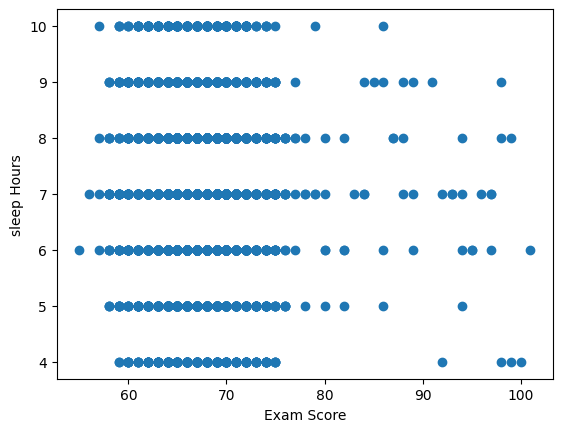

In [58]:
plt.scatter(data= student,x= 'Exam_Score',y='Sleep_Hours')
plt.xlabel('Exam Score')
plt.ylabel('sleep Hours')

Text(0, 0.5, 'Hours Studied')

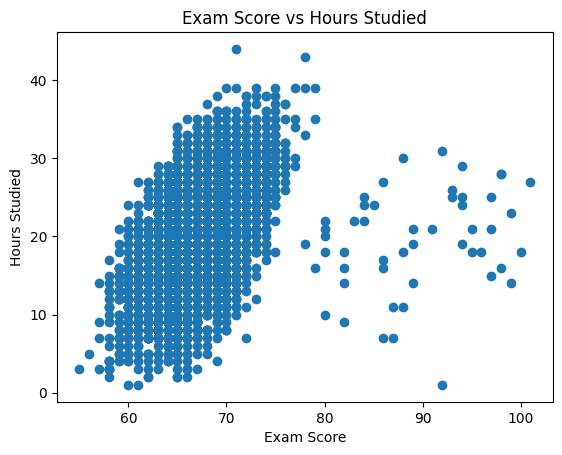

In [63]:
plt.scatter(data= student, x='Exam_Score',y='Hours_Studied')
plt.title('Exam Score vs Hours Studied')
plt.xlabel('Exam Score')
plt.ylabel('Hours Studied')


Text(13.819444444444445, 0.5, 'Hours Studied')

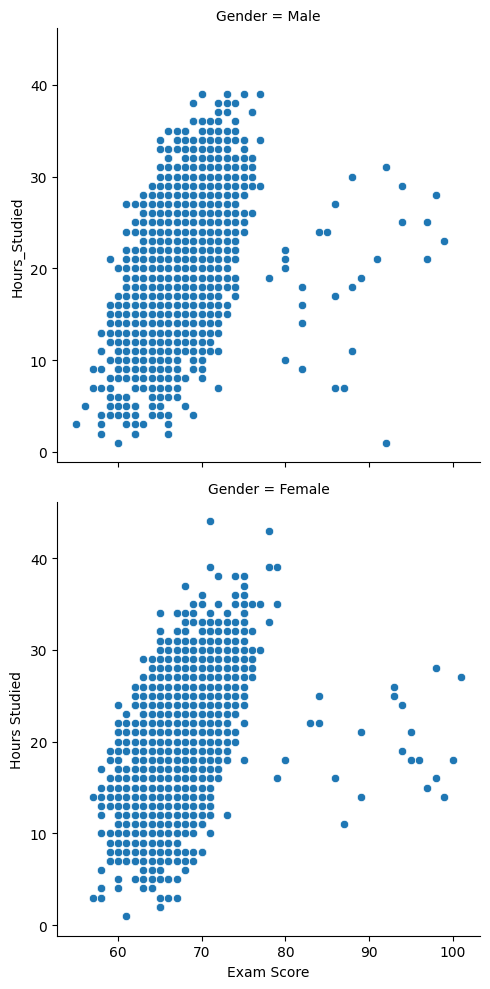

In [71]:
sns.relplot(data=student, x='Exam_Score', y='Hours_Studied', row='Gender', kind='scatter')

plt.xlabel('Exam Score')
plt.ylabel('Hours Studied')


/tmp/ipykernel_92090/434823636.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


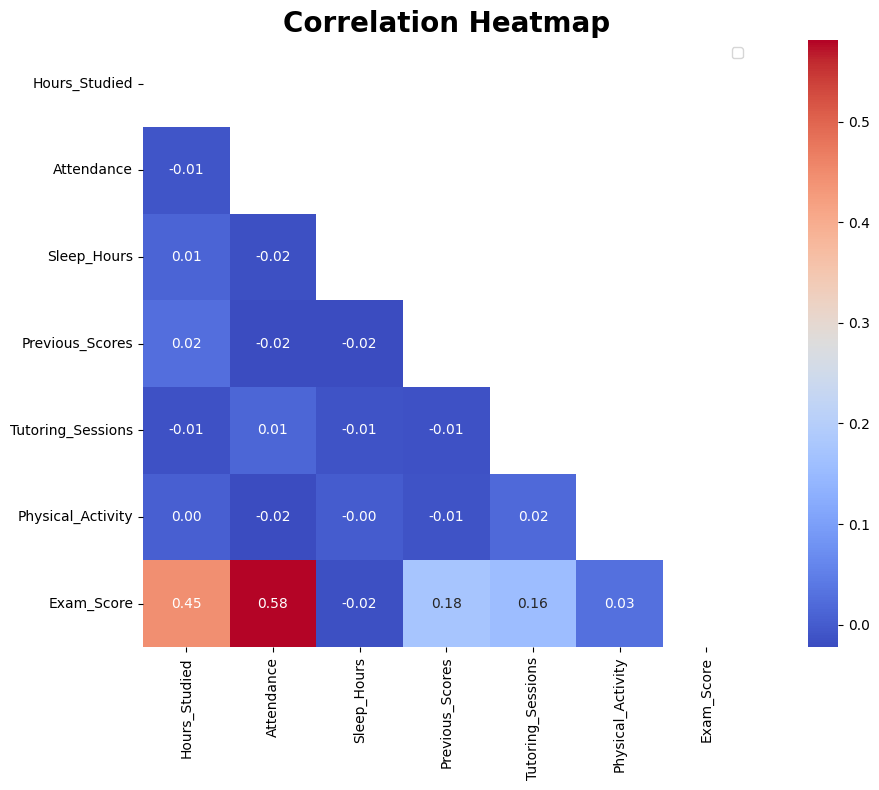

In [64]:
student.copy()
num_df = student.select_dtypes(include='number') #keeps only numeric columns and removes categorical (object, string, etc.)

# Heatmap (using seaborn)

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(
    num_df.corr(), annot=True, fmt='.2f',
    cmap='coolwarm', square=True, mask=mask, # mask=mask: for avoiding dupplications
    annot_kws={'size':10},
)

plt.title('Correlation Heatmap', fontweight= 'bold', fontsize=20)
plt.tight_layout()
plt.legend()

/tmp/ipykernel_104261/2558709344.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = plt.boxplot(student[col].dropna(), labels=[col])


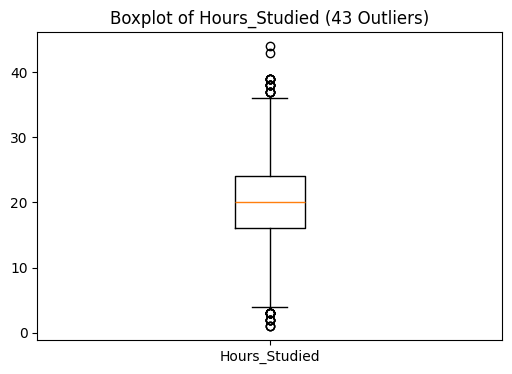

Attendance has no outliers
Sleep_Hours has no outliers
Previous_Scores has no outliers


/tmp/ipykernel_104261/2558709344.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = plt.boxplot(student[col].dropna(), labels=[col])
/tmp/ipykernel_104261/2558709344.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = plt.boxplot(student[col].dropna(), labels=[col])
/tmp/ipykernel_104261/2558709344.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = plt.boxplot(student[col].dropna(), labels=[col])
/tmp/ipykernel_104261/2558709344.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropp

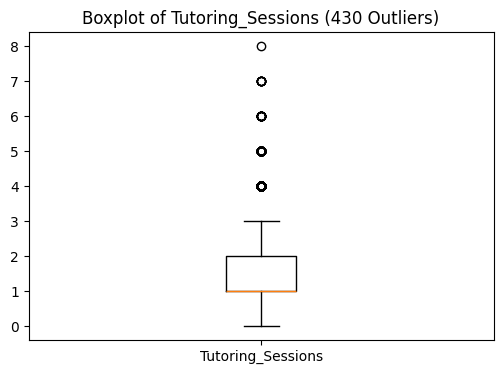

Physical_Activity has no outliers


/tmp/ipykernel_104261/2558709344.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = plt.boxplot(student[col].dropna(), labels=[col])
/tmp/ipykernel_104261/2558709344.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = plt.boxplot(student[col].dropna(), labels=[col])


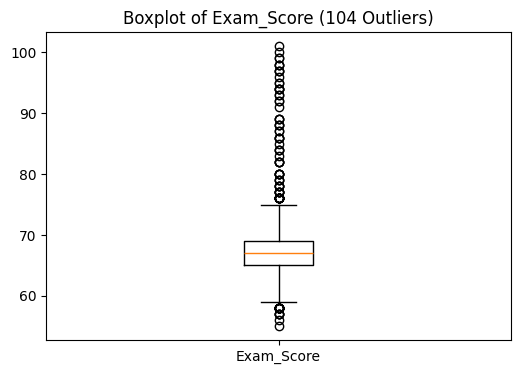

In [16]:
numeric_cols = student.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    
    # Matplotlib's boxplot returns a dictionary of the components
    result = plt.boxplot(student[col].dropna(), labels=[col])
    
    # 'fliers' are the outlier points
    outlier_count = len(result['fliers'][0].get_data()[0])
    
    if outlier_count > 0:
        plt.title(f'Boxplot of {col} ({outlier_count} Outliers)')
        plt.show()
    else:
        plt.close() # Close the figure if we don't want to show it
        print(f"{col} has no outliers")

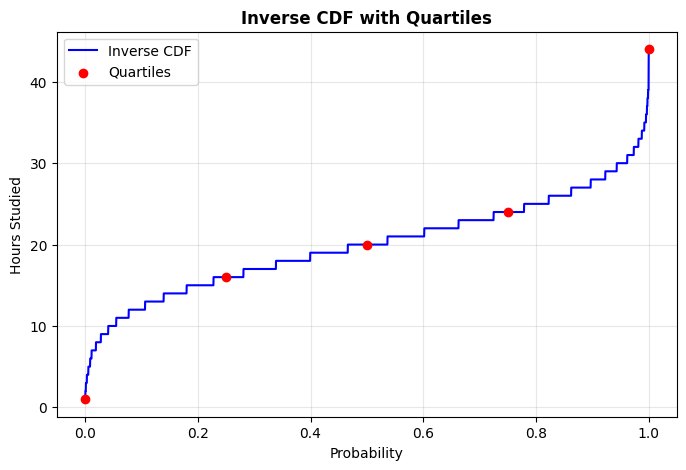

In [19]:
data = student['Hours_Studied'].sort_values()
n = len(data)

# 2. Define y (probabilities from 0 to 1) and x (the sorted values)
y = np.linspace(0, 1, n)
x = data.values

# 3. Your plotting code
Q = [data.quantile(i) for i in [0, 0.25, 0.5, 0.75, 1]]

plt.figure(figsize=(8, 5))
# Note: For an Inverse CDF, usually x (data) is on the Y-axis 
# and y (probability) is on the X-axis
plt.plot(y, x, label='Inverse CDF', color='blue')
plt.scatter([0, 0.25, 0.5, 0.75, 1], Q, color='red', zorder=5, label='Quartiles')

plt.title('Inverse CDF with Quartiles', fontweight='bold')
plt.xlabel('Probability')
plt.ylabel('Hours Studied')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
summary = student.groupby('Gender')[['Exam_Score', 'Hours_Studied', 'Sleep_Hours']].describe()
print(summary)

       Exam_Score                                                      \
            count       mean       std   min   25%   50%   75%    max   
Gender                                                                  
Female     2793.0  67.244898  4.054451  57.0  65.0  67.0  69.0  101.0   
Male       3814.0  67.228894  3.766360  55.0  65.0  67.0  69.0   99.0   

       Hours_Studied             ...             Sleep_Hours            \
               count       mean  ...   75%   max       count      mean   
Gender                           ...                                     
Female        2793.0  20.005013  ...  24.0  44.0      2793.0  7.041890   
Male          3814.0  19.953592  ...  24.0  39.0      3814.0  7.019664   

                                            
             std  min  25%  50%  75%   max  
Gender                                      
Female  1.458610  4.0  6.0  7.0  8.0  10.0  
Male    1.475166  4.0  6.0  7.0  8.0  10.0  

[2 rows x 24 columns]


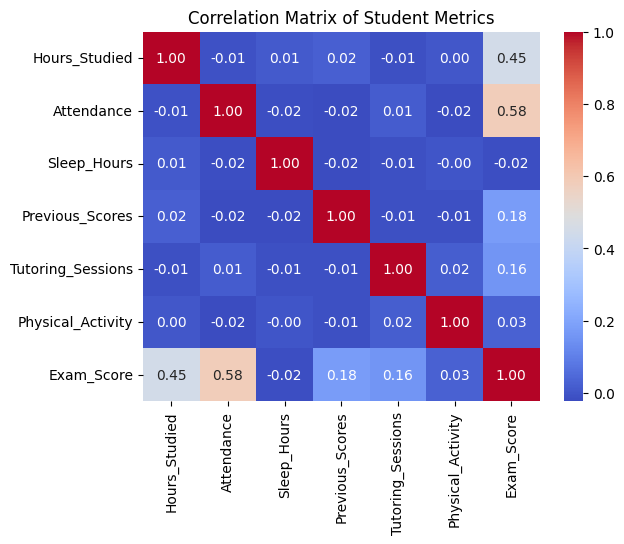

In [21]:
corr = student.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Student Metrics')
plt.show()

Text(0.5, 1.0, 'Average Exam Score by Gender')

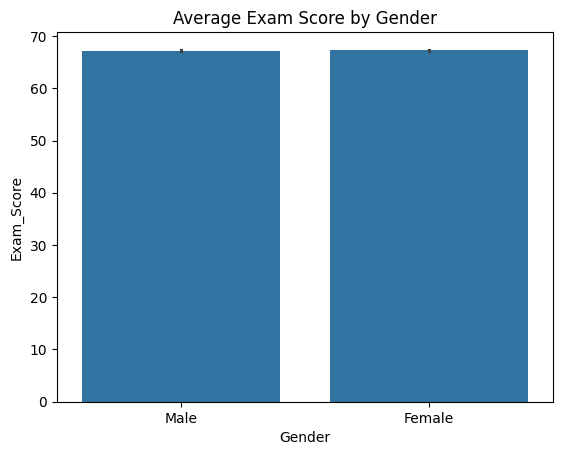

In [22]:
sns.barplot(data=student, x='Gender', y='Exam_Score', estimator='mean')
plt.title('Average Exam Score by Gender')

Text(0.5, 1.0, 'Study Efficiency Distribution by Gender')

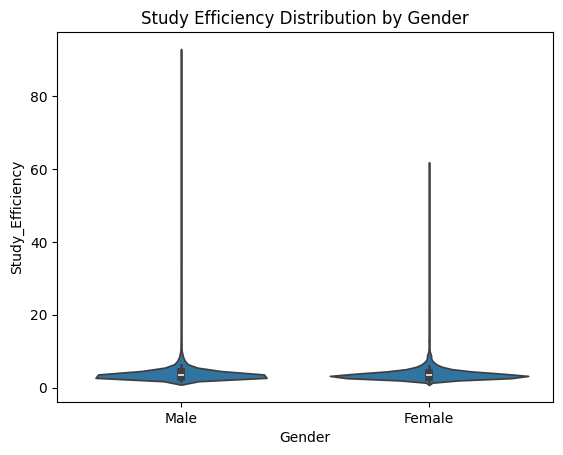

In [23]:
student['Study_Efficiency'] = student['Exam_Score'] / student['Hours_Studied']

# Visualize who is more efficient
sns.violinplot(data=student, x='Gender', y='Study_Efficiency')
plt.title('Study Efficiency Distribution by Gender')

Text(0.5, 1.0, 'Score Distribution by Attendance Category')

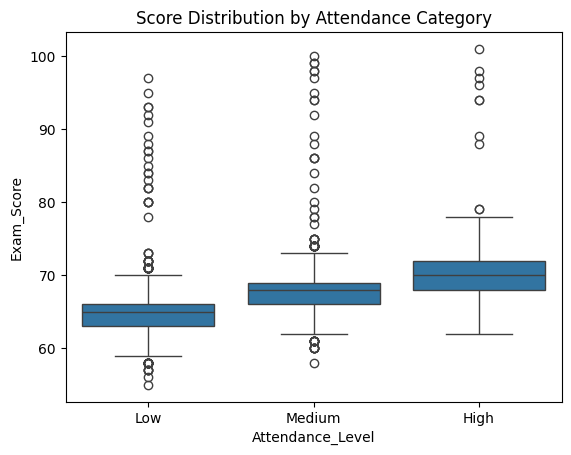

In [24]:
student['Attendance_Level'] = pd.cut(student['Attendance'], 
                                     bins=[0, 75, 90, 100], 
                                     labels=['Low', 'Medium', 'High'])

sns.boxplot(data=student, x='Attendance_Level', y='Exam_Score')
plt.title('Score Distribution by Attendance Category')

### Summary

Our analysis shows that while Study Hours are the strongest predictor of success, there is a significant 'diminishing return' after a certain point. We identified specific outliers who may need different teaching strategies, and our Gender analysis suggests that study efficiency is [consistent/varied] across the group. Sleep remains a wildcard factor that often separates the top 10% from the rest.

The Attendance column is often the "hidden driver" of academic success. While study hours show how hard a student works at home, attendance shows how much direct instruction and peer interaction they are getting.

Research consistently shows that attendance above 90-95% is strongly linked to higher grades, while "chronic absenteeism" (missing just 2 days a month) is often the first warning sign of a dropping GPA.